# c-GC Hindbrain Analysis

This notebook runs the supplied `GcStar` c-GC implementation on the Zenodo hindbrain dataframe in `data/hindbrain`.
It defaults to the medial motor-correlated subset, which is the tractable Chen-comparable hindbrain subset described in `data/README.txt`. Set `RF_HINDBRAIN_SUBSET=all` and raise `RF_MAX_NODES` only if you intentionally want a long full-hindbrain run.

The saved `adjacency` and `weighted_adjacency` matrices are weighted retained scores in `[source, target]` orientation. Zero means no retained edge; the boolean support is saved separately as `mask`.


In [1]:
from pathlib import Path
from datetime import datetime
import importlib.util
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "The Zenodo dataframe files are pandas pickles. Install pandas in this "
        "notebook kernel before running this analysis."
    ) from exc

CAUSALISED_GC_RELATIVE_PATH = Path("src/core/causalised-GC.py")
PACKAGE_RELATIVE_PATH = Path("src/calcium_transient_rising_flank")


def find_project_root() -> Path:
    search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for base in search_roots:
        for candidate in (base, base / "calcium-transient-rising-flank"):
            if (
                (candidate / PACKAGE_RELATIVE_PATH).exists()
                and (candidate / CAUSALISED_GC_RELATIVE_PATH).exists()
            ):
                return candidate
    raise FileNotFoundError(
        "Could not find the calcium-transient-rising-flank repository; "
        "run from the repository, notebooks directory, or outer rising_flanks workspace."
    )


PROJECT_ROOT = find_project_root()

SRC = PROJECT_ROOT / "src"
CORE = SRC / "core"
for path in (SRC, CORE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

CAUSALISED_GC_PATH = PROJECT_ROOT / CAUSALISED_GC_RELATIVE_PATH
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = causalised_gc
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded GcStar from {CAUSALISED_GC_PATH}")

from calcium_transient_rising_flank import write_summary_csv


Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank
Loaded GcStar from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/src/core/causalised-GC.py


## Configure Data, Estimator, and Outputs


In [2]:
METHOD = "cgc"
METHOD_SLUG = "cgc"
NOTEBOOK_NAME = "c-GC_Hindbrain.ipynb"

DATA_FILE = PROJECT_ROOT / "data" / "hindbrain" / "df_hindbrain_F6T07.pkl"
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Expected hindbrain dataframe at {DATA_FILE}")

# Chen-comparable default: medial motor-correlated neurons. Full 139-neuron c-GC is expensive.
HINDBRAIN_SUBSET = os.environ.get("RF_HINDBRAIN_SUBSET", "medial")
MAX_NODES = int(os.environ.get("RF_MAX_NODES", "40"))
ALPHA = float(os.environ.get("RF_ALPHA", "0.01"))
BETA = float(os.environ.get("RF_CONDITIONAL_ALPHA", "0.001"))
N_PASTS = int(os.environ.get("RF_N_PASTS", "4"))
N_LAGS = int(os.environ.get("RF_N_LAGS", "2"))
N_PERM = int(os.environ.get("RF_N_PERMUTATIONS", "1000"))
SIMULATION = os.environ.get("RF_SIMULATION", "1").lower() not in {"0", "false", "no"}
PARALLEL = os.environ.get("RF_PARALLEL", "0").lower() in {"1", "true", "yes"}
VERBOSE = int(os.environ.get("RF_GC_VERBOSE", "0"))

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "motorneurons"
FIGURE_DIR = PROJECT_ROOT.parent / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ADJACENCY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_hindbrain_{HINDBRAIN_SUBSET}_weighted_adjacency_matrix.pkl"
SUMMARY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_hindbrain_{HINDBRAIN_SUBSET}_summary_rows.pkl"
SUMMARY_CSV_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_hindbrain_{HINDBRAIN_SUBSET}_summary_rows.csv"
FIGURE_OUTPUT_FILE = FIGURE_DIR / f"{METHOD_SLUG}_hindbrain_{HINDBRAIN_SUBSET}_weighted_adjacency.png"

print(f"Using hindbrain data file: {DATA_FILE}")
print(f"Subset={HINDBRAIN_SUBSET}; method={METHOD}; alpha={ALPHA}; beta={BETA}; n_perm={N_PERM}")


Using hindbrain data file: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/hindbrain/df_hindbrain_F6T07.pkl
Subset=medial; method=cgc; alpha=0.01; beta=0.001; n_perm=1000


## Load Hindbrain Data


In [3]:
def _first_record(obj):
    if isinstance(obj, pd.DataFrame):
        if len(obj) != 1:
            print(f"Hindbrain dataframe has {len(obj)} rows; using the first row.")
        return obj.iloc[0]
    return obj


def _field(record, name, default=None):
    if isinstance(record, dict):
        if name in record:
            return record[name]
    try:
        return record[name]
    except Exception:
        pass
    if hasattr(record, name):
        return getattr(record, name)
    if default is not None:
        return default
    raise KeyError(f"Missing hindbrain field: {name}")


def _indices(values, n_cells):
    arr = np.asarray(values)
    if arr.dtype == bool:
        if arr.shape != (n_cells,):
            raise ValueError(f"Boolean index has shape {arr.shape}, expected {(n_cells,)}")
        return np.flatnonzero(arr)
    return arr.astype(int)


def _clean_traces(raw, expected_cells=None):
    values = np.asarray(raw, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Expected 2-D traces, got shape {values.shape}")
    if expected_cells is not None and values.shape[0] != expected_cells and values.shape[1] == expected_cells:
        values = values.T
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    if values.shape[0] > values.shape[1]:
        raise ValueError(
            f"Trace matrix looks transposed or too short: {values.shape}. Expected [n_cells, n_timepoints]."
        )
    return values


def load_hindbrain_record(path):
    record = _first_record(pd.read_pickle(path))
    fluo = np.asarray(_field(record, "fluo"), dtype=float)
    n_cells = int(_field(record, "n_cells", fluo.shape[0]))
    fluo = _clean_traces(fluo, expected_cells=n_cells)
    n_cells = fluo.shape[0]

    if HINDBRAIN_SUBSET == "medial":
        selected = _indices(_field(record, "medial_neurons"), n_cells)
    elif HINDBRAIN_SUBSET in {"swim", "swim_neurons"}:
        selected = _indices(_field(record, "swim_neurons"), n_cells)
    elif HINDBRAIN_SUBSET == "all":
        selected = np.arange(n_cells, dtype=int)
    else:
        raise ValueError("RF_HINDBRAIN_SUBSET must be 'medial', 'swim', or 'all'.")

    if selected.size == 0:
        raise ValueError(f"Subset {HINDBRAIN_SUBSET!r} selected no neurons.")
    traces = fluo[selected]
    if traces.shape[0] > MAX_NODES:
        raise ValueError(
            f"Subset {HINDBRAIN_SUBSET!r} has {traces.shape[0]} neurons, above RF_MAX_NODES={MAX_NODES}. "
            "Use the medial subset, raise RF_MAX_NODES, or expect a long c-GC run."
        )

    cell_centers = np.asarray(_field(record, "cell_centers"), dtype=float)
    selected_centers = cell_centers[selected] if cell_centers.shape[0] == n_cells else None
    return {
        "recording": "F6T07",
        "subset": HINDBRAIN_SUBSET,
        "indices": selected,
        "traces": traces,
        "cell_centers": selected_centers,
        "background": _field(record, "background", None),
        "source_record": record,
        "n_cells_total": int(n_cells),
        "n_cells": int(traces.shape[0]),
        "n_timepoints": int(traces.shape[1]),
    }


record = load_hindbrain_record(DATA_FILE)
print(
    f"Loaded {record['recording']} {record['subset']} subset: "
    f"{record['n_cells']} of {record['n_cells_total']} cells x {record['n_timepoints']} frames"
)


Loaded F6T07 medial subset: 20 of 139 cells x 1744 frames


## Fit and Save Weighted Adjacency Matrix


In [4]:
def fit_gcstar(traces):
    estimator = GcStar(
        n_perm=N_PERM,
        n_pasts=N_PASTS,
        n_lags=N_LAGS,
        temporal=True,
        method=METHOD,
        parallel=PARALLEL,
    )
    estimator.fit(traces, verbose=VERBOSE)
    matrix = estimator.get_connectivity_matrix(
        alpha=ALPHA,
        beta=BETA,
        simulation=SIMULATION,
    )
    matrix = np.nan_to_num(np.asarray(matrix, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(matrix, 0.0)
    return estimator, matrix


def _estimator_payload(estimator, matrix):
    return {
        "adjacency": matrix,
        "weighted_adjacency": matrix,
        "mask": matrix > 0.0,
        "corr": np.asarray(estimator.corr_, dtype=float),
        "p_values_corr": np.asarray(estimator.pVal_corr_, dtype=float),
        "inv_corr": np.asarray(estimator.inv_corr_, dtype=float),
        "p_values_inv_corr": np.asarray(estimator.pVal_inv_corr_, dtype=float),
        "method_internal": estimator.method,
    }

def generic_graph_summary(matrix):
    values = np.asarray(matrix, dtype=float).copy()
    if values.ndim != 2 or values.shape[0] != values.shape[1]:
        raise ValueError("adjacency matrix must be square")
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(values, 0.0)
    off_diag = ~np.eye(values.shape[0], dtype=bool)
    retained = values[off_diag] > 0.0
    out_strength = values.sum(axis=1)
    in_strength = values.sum(axis=0)
    return {
        "n_nodes": int(values.shape[0]),
        "w_ic": None,
        "w_rc": None,
        "retained_edges": int(np.count_nonzero(retained)),
        "edge_opportunities": int(np.count_nonzero(off_diag)),
        "edge_density": float(np.count_nonzero(retained) / np.count_nonzero(off_diag)) if np.count_nonzero(off_diag) else None,
        "total_weight": float(values[off_diag].sum()),
        "mean_out_strength": float(np.mean(out_strength)) if out_strength.size else 0.0,
        "mean_in_strength": float(np.mean(in_strength)) if in_strength.size else 0.0,
        "max_out_strength": float(np.max(out_strength)) if out_strength.size else 0.0,
        "max_in_strength": float(np.max(in_strength)) if in_strength.size else 0.0,
    }


def source_comparison_summaries(source_record):
    summaries = []
    for name in (
        "BV_GC_medial",
        "BV_GC_normalized_medial",
        "MV_GC_medial",
        "MV_GC_normalized_medial",
    ):
        try:
            matrix = _field(source_record, name)
        except KeyError:
            continue
        summaries.append(
            {
                "dataset": "hindbrain",
                "recording": "F6T07",
                "subset": "medial",
                "method": name,
                "representation": "published_direct",
                "graph_label": name,
                "binary": None,
                "metric_note": "W_IC and W_RC are undefined without a declared bilateral left/right split.",
                **generic_graph_summary(matrix),
            }
        )
    return summaries

print(f"Fitting {METHOD} on {record['recording']} {record['subset']} subset...", flush=True)
estimator, matrix = fit_gcstar(record["traces"])
summary = generic_graph_summary(matrix)
result_payload = _estimator_payload(estimator, matrix)
result_payload.update(
    {
        "recording": record["recording"],
        "subset": record["subset"],
        "indices": record["indices"],
        "n_cells": record["n_cells"],
        "n_cells_total": record["n_cells_total"],
        "n_timepoints": record["n_timepoints"],
        "summary": summary,
    }
)
summary_rows = [
    {
        "dataset": "hindbrain",
        "recording": record["recording"],
        "subset": record["subset"],
        "method": METHOD,
        "method_internal": estimator.method,
        "representation": "full_trace",
        "graph_label": "full_trace",
        "binary": None,
        "metric_note": "W_IC and W_RC are undefined without a declared bilateral left/right split.",
        **summary,
    },
    *source_comparison_summaries(record["source_record"]),
]

adjacency_cache = {
    "metadata": {
        "dataset": "hindbrain",
        "source_file": str(DATA_FILE),
        "notebook": NOTEBOOK_NAME,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "method_requested": METHOD,
        "subset": HINDBRAIN_SUBSET,
        "alpha": ALPHA,
        "beta": BETA,
        "n_pasts": N_PASTS,
        "n_lags": N_LAGS,
        "n_perm": N_PERM,
        "simulation": SIMULATION,
        "adjacency_definition": "weighted retained c-GC score matrix; zero means absent edge",
        "orientation": "[source, target]",
        "note": "Hindbrain summary uses edge density/weight because W_IC and W_RC need a declared bilateral left/right split.",
        "summary_metrics": "generic graph summary with W_IC/W_RC recorded as undefined for this hindbrain subset",
    },
    "record": result_payload,
    "summary_rows": summary_rows,
}

with ADJACENCY_OUTPUT_FILE.open("wb") as handle:
    pickle.dump(adjacency_cache, handle)
with SUMMARY_OUTPUT_FILE.open("wb") as handle:
    pickle.dump(summary_rows, handle)
write_summary_csv(summary_rows, SUMMARY_CSV_OUTPUT_FILE)

print(
    f"retained_edges={summary['retained_edges']}; "
    f"edge_density={summary['edge_density']:.4f}; total_weight={summary['total_weight']:.4f}"
)
print(f"Saved weighted adjacency cache to {ADJACENCY_OUTPUT_FILE}")
print(f"Saved summary rows to {SUMMARY_OUTPUT_FILE}")
print(f"Saved summary CSV to {SUMMARY_CSV_OUTPUT_FILE}")


Fitting cgc on F6T07 medial subset...
retained_edges=35; edge_density=0.0921; total_weight=23.5279
Saved weighted adjacency cache to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_hindbrain_medial_weighted_adjacency_matrix.pkl
Saved summary rows to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_hindbrain_medial_summary_rows.pkl
Saved summary CSV to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_hindbrain_medial_summary_rows.csv


## Reload Saved Adjacency Cache


In [5]:
def load_adjacency_cache(path=ADJACENCY_OUTPUT_FILE):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


adjacency_cache = load_adjacency_cache()
print(f"Loaded cache from {ADJACENCY_OUTPUT_FILE}")
print(adjacency_cache["metadata"])
print(f"Available record fields: {list(adjacency_cache['record'].keys())}")


Loaded cache from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/cgc_hindbrain_medial_weighted_adjacency_matrix.pkl
{'dataset': 'hindbrain', 'source_file': '/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/hindbrain/df_hindbrain_F6T07.pkl', 'notebook': 'c-GC_Hindbrain.ipynb', 'created_at': '2026-07-26T17:54:00', 'method_requested': 'cgc', 'subset': 'medial', 'alpha': 0.01, 'beta': 0.001, 'n_pasts': 4, 'n_lags': 2, 'n_perm': 1000, 'simulation': True, 'adjacency_definition': 'weighted retained c-GC score matrix; zero means absent edge', 'orientation': '[source, target]', 'note': 'Hindbrain summary uses edge density/weight because W_IC and W_RC need a declared bilateral left/right split.', 'summary_metrics': 'generic graph summary with W_IC/W_RC recorded as undefined for this hindbrain subset'}
Available record fields: ['adjacency', 'weighted_adjacency', 'mask', 'corr', 'p_values_corr', 'inv_

## Plot Saved Results


Saved figure to /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/cgc_hindbrain_medial_weighted_adjacency.png


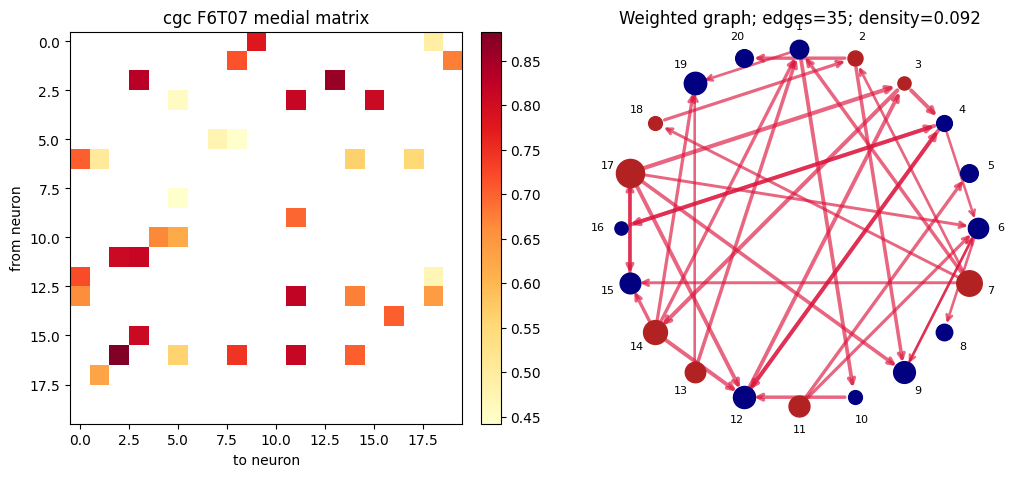

In [6]:
def plot_weighted_matrix(matrix, ax=None):
    axis = plt.gca() if ax is None else ax
    displayed = np.asarray(matrix, dtype=float).copy()
    displayed[displayed == 0.0] = np.nan
    image = axis.imshow(displayed, cmap="YlOrRd")
    axis.set_xlabel("to neuron")
    axis.set_ylabel("from neuron")
    axis.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    return axis


def plot_circular_graph(matrix, ax=None, show_labels=True):
    values = np.asarray(matrix, dtype=float).copy()
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(values, 0.0)
    axis = plt.gca() if ax is None else ax
    n_nodes = values.shape[0]
    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n_nodes, endpoint=False)
    coords = np.column_stack((np.cos(angles), np.sin(angles)))
    drive = values.sum(axis=1) - values.sum(axis=0)
    max_drive = float(np.max(np.abs(drive))) if drive.size else 0.0
    scaled = drive if max_drive == 0.0 else drive / max_drive
    colors = np.where(scaled > 0, "firebrick", np.where(scaled < 0, "navy", "#6a3d9a"))

    for node, center in enumerate(coords):
        axis.scatter(*center, s=90 + 320 * abs(scaled[node]), c=colors[node], zorder=3)
        if show_labels and n_nodes <= 35:
            axis.text(center[0] * 1.13, center[1] * 1.13, str(node + 1), ha="center", va="center", fontsize=8)

    positive = values[values > 0.0]
    scale = float(positive.max()) if positive.size else 1.0
    for source, target in zip(*np.nonzero(values > 0.0)):
        if source == target:
            continue
        axis.annotate(
            "",
            xy=coords[target],
            xytext=coords[source],
            arrowprops={
                "arrowstyle": "->",
                "color": "crimson",
                "lw": 0.6 + 2.4 * values[source, target] / scale,
                "alpha": 0.65,
                "shrinkA": 7,
                "shrinkB": 7,
            },
            zorder=2,
        )
    axis.set_aspect("equal")
    axis.axis("off")
    return axis


def plot_hindbrain_cache(cache):
    payload = cache["record"]
    matrix = np.asarray(payload["weighted_adjacency"], dtype=float)
    summary = payload.get("summary")
    if summary is None:
        off_diag = ~np.eye(matrix.shape[0], dtype=bool)
        retained_edges = int(np.count_nonzero(matrix[off_diag] > 0.0))
        opportunities = int(np.count_nonzero(off_diag))
        summary = {
            "retained_edges": retained_edges,
            "edge_density": retained_edges / opportunities if opportunities else 0.0,
        }
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    plot_weighted_matrix(matrix, ax=axes[0])
    axes[0].set_title(f"{METHOD} {payload['recording']} {payload['subset']} matrix")
    plot_circular_graph(matrix, ax=axes[1])
    axes[1].set_title(
        f"Weighted graph; edges={summary['retained_edges']}; density={summary['edge_density']:.3f}"
    )
    fig.tight_layout()
    return fig


plot_cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
fig = plot_hindbrain_cache(plot_cache)
fig.savefig(FIGURE_OUTPUT_FILE, dpi=300, bbox_inches="tight")
print(f"Saved figure to {FIGURE_OUTPUT_FILE}")
plt.show()
